<a href="https://colab.research.google.com/github/caiohamamura/forestsat2026_rgedi_workshop/blob/main/rgedi_incolab_version.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
###############################################################################
# Workshop:
# Introduction to NASA's GEDI and rGEDI:
# An R Package for Accessing, Handling, and Processing GEDI Data
#
# Authors:
# Dr. Inacio Bueno
# Dr. Caio Hamamura
#
# Description:
# This script is part of a workshop designed to introduce participants to
# NASA's Global Ecosystem Dynamics Investigation (GEDI) mission and to the
# rGEDI package in R for accessing, handling, visualizing, and processing
# GEDI data products.
#
###############################################################################

rm(list = ls())
gc()

# 1. Packages -------------------------------------------------------------
# In this section, we check whether the packages required for the workshop
# are available in the current R environment.

# List of required CRAN packages for this workshop.
packages <- c("remotes", "sf", "leaflet", "ggplot2", "terra", "raster", "rasterVis", "viridis")


,used,(Mb),gc trigger,(Mb),max used,(Mb)
Ncells,657415,35.2,1455114,77.8,1341196,71.7
Vcells,1220169,9.4,8388608,64.0,1975133,15.1


In [ ]:
options(repos = c(
  RSPM = "https://packagemanager.posit.co/cran/__linux__/jammy/latest"
))

if (require("pak") == FALSE) {
  install.packages("pak")
}

pak::pak("tidyverse")

Loading required package: pak



✔ Updated metadata database: 5.83 MB in 10 files.



ℹ Updating metadata database

✔ Updating metadata database ... done



 

→ Will install 96 packages.

→ Will download 96 packages with unknown size.

+ askpass         1.2.1    [dl]
+ backports       1.5.0    [dl]
+ base64enc       0.1-6    [dl]
+ bit             4.6.0    [dl]
+ bit64           4.6.0-1  [dl]
+ blob            1.3.0    [dl]
+ broom           1.0.12   [dl]
+ bslib           0.10.0   [dl]
+ cachem          1.1.0    [dl]
+ callr           3.7.6    [dl]
+ cellranger      1.1.0    [dl]
+ cli             3.6.5    [dl]
+ clipr           0.8.0    [dl] + ✔ libx11-dev
+ conflicted      1.2.0    [dl]
+ crayon          1.5.3    [dl]
+ curl            7.0.0    [dl] + ✔ libcurl4-openssl-dev, ✔ libssl-dev
+ data.table      1.18.2.1 [dl]
+ DBI             1.3.0    [dl]
+ dbplyr          2.5.2    [dl]
+ digest          0.6.39   [dl]
+ dplyr           1.2.0    [dl]
+ dtplyr          1.3.3    [dl]
+ eva

In [ ]:
# Identify which CRAN packages are missing from the current R environment.
missing_pkg <- packages[
  !sapply(packages, requireNamespace, quietly = TRUE)
]

# Install missing CRAN packages, if needed.
if (length(missing_pkg) > 0) {
  pak::pak(
    missing_pkg
  )
}

# Check whether rGEDI is installed.If not, install it from GitHub using the remotes package.
if (!requireNamespace("rGEDI", quietly = TRUE)) {
  pak::pkg_install(
    "carlos-alberto-silva/rGEDI",
    dependencies = TRUE
  )
}

 

→ Will install 31 packages.

→ Will download 1 CRAN package (1.07 MB).

→ Will download 30 packages with unknown size.

+ class               7.3-23  [dl]
+ classInt            0.4-11  [dl]
+ crosstalk           1.2.2   [dl]
+ deldir              2.0-4   [dl]
+ e1071               1.7-17  [dl]
+ gridExtra           2.3     [dl]
+ hexbin              1.28.5  [dl]
+ htmlwidgets         1.6.4   [dl]
+ interp              1.1-6   [dl]
+ jpeg                0.1-11  [dl] + ✔ libjpeg-dev
+ KernSmooth          2.23-26 [dl]
+ lattice             0.22-9  [dl]
+ latticeExtra        0.6-31  [dl]
+ lazyeval            0.2.2   [dl]
+ leaflet             2.2.3   [dl]
+ leaflet.providers   3.0.0   [dl]
+ MASS                7.3-65  [dl]
+ png                 0.1-9   [dl] + ✔ libpng-dev
+ proxy               0.4-29  [dl]
+ raster              3.6-32  [dl]
+ rasterVis           0.51.7  [dl]
+ Rcpp                1.1.1   [dl]
+ remotes             2.5.0   [dl] + ✔ git
+ s2                  1.1.9   [dl

In [ ]:
install.packages("sf", type = "source")

Installing package into ‘/usr/local/lib/R/site-library’
(as ‘lib’ is unspecified)



In [ ]:
# Load all required packages.
library(remotes)
library(rGEDI)
library(leaflet)
library(ggplot2)
library(sf)
library(terra)
library(raster)
library(leaflet)
library(ggplot2)
library(viridis)

Linking to GEOS 3.12.1, GDAL 3.8.4, PROJ 9.3.1; sf_use_s2() is TRUE

terra 1.9.11

Loading required package: sp

Loading required package: viridisLite



In [ ]:
# ##########################################################################
# 2. Define the study area and download GEDI data -------------------------
# In this section, users can define the study area, date range,and output
# folder for saving GEDI files.

# Select output directory
outdir <- getwd(); cat("Selected download directory:\n", outdir, "\n")

# Bounding box coordinates for the study area
# ul = upper left
# lr = lower right
ul_lat <- 29.77
lr_lat <- 29.73
ul_lon <- -82.24
lr_lon <- -82.19

# Download and unzip
download.file('https://raw.githubusercontent.com/caiohamamura/forestsat2026_rgedi_workshop/refs/heads/main/aoi.zip', 'aoi.zip')
unzip('aoi.zip')

# Shapefile for the study area
polygon_filepath <- "aoi.shp"

# Define the start and end dates for the GEDI data search
daterange <- c("2020-01-01", "2020-05-31")




Selected download directory:
 /content 


In [ ]:
# ##########################################################################
# 3. Search and download GEDI data -----------------------------------------
# In this section, the script searches for GEDI Level 1B, Level 2A, and Level
# 2B files that intersect the study area and date range, then downloads the
# available files to the selected output directory.
#
# For workshop purposes, only the first file found for each product is
# downloaded. This helps reduce download time and keeps the example simple

# Search for GEDI Level 1B files
gLevel1B <- gedifinder(
  product   = "GEDI01_B",
  ul_lat    = ul_lat,
  ul_lon    = ul_lon,
  lr_lat    = lr_lat,
  lr_lon    = lr_lon,
  version   = "002",
  daterange = daterange
)

# Search for GEDI Level 2A files
gLevel2A <- gedifinder(
  product   = "GEDI02_A",
  ul_lat    = ul_lat,
  ul_lon    = ul_lon,
  lr_lat    = lr_lat,
  lr_lon    = lr_lon,
  version   = "002",
  daterange = daterange
)

# Search for GEDI Level 2B files
gLevel2B <- gedifinder(
  product   = "GEDI02_B",
  ul_lat    = ul_lat,
  ul_lon    = ul_lon,
  lr_lat    = lr_lat,
  lr_lon    = lr_lon,
  version   = "002",
  daterange = daterange
)

# Show the number of files found for each product
cat("Number of GEDI files found:\n")
cat("GEDI Level 1B:", length(gLevel1B), "\n")
cat("GEDI Level 2A:", length(gLevel2A), "\n")
cat("GEDI Level 2B:", length(gLevel2B), "\n")

# Keep only the second file of each product for workshop demonstration
if (length(gLevel1B) >= 2) gLevel1B <- gLevel1B[2] else gLevel1B <- character(0)
if (length(gLevel2A) >= 2) gLevel2A <- gLevel2A[2] else gLevel2A <- character(0)
if (length(gLevel2B) >= 2) gLevel2B <- gLevel2B[2] else gLevel2B <- character(0)

Number of GEDI files found:
GEDI Level 1B: 3 
GEDI Level 2A: 3 
GEDI Level 2B: 3 


In [ ]:
# Download GEDI Level 1B files
if (length(gLevel1B) > 0) {
  gediDownload(filepath = gLevel1B, outdir = outdir)
} else {
  cat("No GEDI Level 1B files were found for the selected area and date range.\n")
}

# Download GEDI Level 2A files
if (length(gLevel2A) > 0) {
  gediDownload(filepath = gLevel2A, outdir = outdir)
} else {
  cat("No GEDI Level 2A files were found for the selected area and date range.\n")
}

# Download GEDI Level 2B files
if (length(gLevel2B) > 0) {
  gediDownload(filepath = gLevel2B, outdir = outdir)
} else {
  cat("No GEDI Level 2B files were found for the selected area and date range.\n")
}


Enter NASA Earthdata Login Username 
 (or create an account at urs.earthdata.nasa.gov) :··········
Enter NASA Earthdata Login Password:··········


A saída de streaming foi truncada nas últimas 5000 linhas.
Downloading... 712.50/NAMB (NA%)    
Downloading... 713.00/NAMB (NA%)    
Downloading... 713.50/NAMB (NA%)    
Downloading... 714.00/NAMB (NA%)    
Downloading... 714.50/NAMB (NA%)    
Downloading... 715.00/NAMB (NA%)    
Downloading... 715.50/NAMB (NA%)    
Downloading... 716.00/NAMB (NA%)    
Downloading... 716.50/NAMB (NA%)    
Downloading... 717.00/NAMB (NA%)    
Downloading... 717.50/NAMB (NA%)    
Downloading... 718.00/NAMB (NA%)    
Downloading... 718.50/NAMB (NA%)    
Downloading... 719.00/NAMB (NA%)    
Downloading... 719.50/NAMB (NA%)    
Downloading... 720.00/NAMB (NA%)    
Downloading... 720.50/NAMB (NA%)    
Downloading... 721.00/NAMB (NA%)    
Downloading... 721.50/NAMB (NA%)    
Downloading... 722.00/NAMB (NA%)    
Downloading... 722.50/NAMB (NA%)    
Downloading... 723.00/NAMB (NA%)    
Downloading... 723.50/NAMB (NA%)    
Downloading... 724.00/NAMB (NA%)    
Downloading... 724.50/NAMB (NA%)    
Downloading... 7

# 4. Read, clip, and plot GEDI data

In this section, the script lists the downloaded GEDI files in the selected output directory, reads all available files for each GEDI product, and demonstrates two clipping approaches:
1. Clipping by bounding box
2. Clipping by shapefile geometry

Downloaded GEDI files found in the selected directory:
[1] "GEDI01_B_2020084054801_O07253_03_T01627_02_005_01_V002.h5"
[2] "GEDI02_A_2020084054801_O07253_03_T01627_02_003_01_V002.h5"
[3] "GEDI02_B_2020084054801_O07253_03_T01627_02_003_01_V002.h5"
  |======================================================================| 100%


Warning message:
“attribute variables are assumed to be spatially constant throughout all geometries”


  |======================================================================| 100%


Warning message:
“attribute variables are assumed to be spatially constant throughout all geometries”


  |======================================================================| 100%


...

shot_number,latitude_bin0,latitude_lastbin,longitude_bin0,longitude_lastbin,elevation_bin0,source_file,id,poly_id
<chr>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<chr>,<int>,<dbl>
72530500300430011,29.76135,29.76133,-82.20188,-82.20185,64.44341,GEDI01_B_2020084054801_O07253_03_T01627_02_005_01_V002.h5,1,NA
72530500300430012,29.76098,29.76095,-82.20147,-82.20145,65.00802,GEDI01_B_2020084054801_O07253_03_T01627_02_005_01_V002.h5,2,NA
72530500300430013,29.76061,29.76058,-82.20107,-82.20104,75.66246,GEDI01_B_2020084054801_O07253_03_T01627_02_005_01_V002.h5,3,NA
72530500300430014,29.76023,29.76020,-82.20067,-82.20064,81.77222,GEDI01_B_2020084054801_O07253_03_T01627_02_005_01_V002.h5,4,NA
72530500300430015,29.75986,29.75983,-82.20027,-82.20024,83.37476,GEDI01_B_2020084054801_O07253_03_T01627_02_005_01_V002.h5,5,NA
72530500300430016,29.75948,29.75945,-82.19986,-82.19983,81.92354,GEDI01_B_2020084054801_O07253_03_T01627_02_005_01_V002.h5,6,NA


beam,shot_number,elev_highestreturn,elev_lowestmode,rh100
<chr>,<chr>,<dbl>,<dbl>,<dbl>
BEAM0101,72530500300430011,20.50756,16.76196,3.74
BEAM0101,72530500300430012,20.84743,16.98947,3.85
BEAM0101,72530500300430013,31.68916,16.74423,14.94
BEAM0101,72530500300430014,37.16216,16.63629,20.52
BEAM0101,72530500300430015,38.68979,16.36603,22.32
BEAM0101,72530500300430016,37.46331,16.78762,20.67


Warning message in abbreviate_shapefile_names(obj):
“Field names abbreviated for ESRI Shapefile driver”


Clipped GEDI Level 2A metrics shapefile saved to:
 /content/GEDI_Level2A_Metrics.shp 
  |======================================================================| 100%


Warning message in doTryCatch(return(expr), name, parentenv, handler):
“graphical parameter "type" is obsolete”


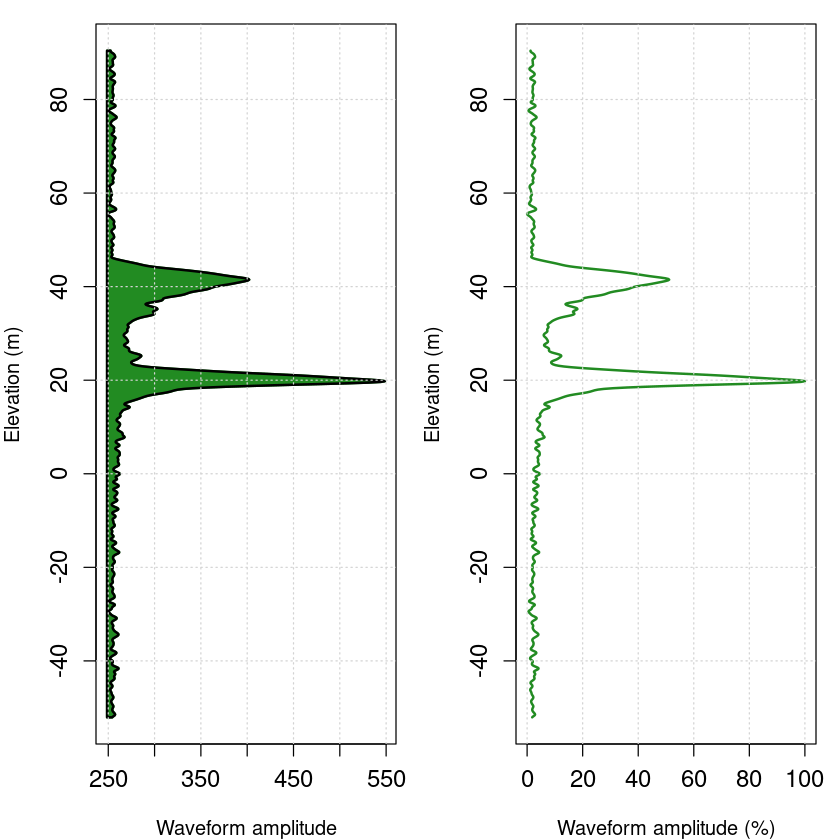

beam,shot_number,pai,fhd_normal,omega,pgap_theta,cover
<int>,<chr>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>
5,72530500300430011,0.0652499,1.302189,1,0.9678863,0.03209824
5,72530500300430012,0.0576965,1.399771,1,0.9715503,0.02843591
5,72530500300430013,0.1854234,2.714054,1,0.9114154,0.08854180
5,72530500300430014,0.2876350,2.901495,1,0.8659856,0.13394967
5,72530500300430015,2.4940066,2.966522,1,0.2871915,0.71246415
5,72530500300430016,1.3749168,2.863483,1,0.5026854,0.49707431


beam,shot_number,algorithmrun_flag,l2b_quality_flag,delta_time,sensitivity,solar_elevation,latitude_lastbin,latitude_bin0,longitude_bin0,⋯,elev_lowestmode,rh100,pai,fhd_normal,omega,pgap_theta,cover,source_file,id,poly_id
<int>,<chr>,<int>,<int>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,⋯,<dbl>,<int>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<chr>,<int>,<dbl>
5,72530500300430011,1,1,70267634,0.9670780,-54.20636,29.76134,29.76134,-82.20187,⋯,16.76196,374,0.0652499,1.302189,1,0.9678863,0.03209824,GEDI02_B_2020084054801_O07253_03_T01627_02_003_01_V002.h5,1,NA
5,72530500300430012,1,1,70267634,0.9712204,-54.20648,29.76097,29.76097,-82.20146,⋯,16.98947,384,0.0576965,1.399771,1,0.9715503,0.02843591,GEDI02_B_2020084054801_O07253_03_T01627_02_003_01_V002.h5,2,NA
5,72530500300430013,1,1,70267634,0.9756637,-54.20660,29.76059,29.76060,-82.20106,⋯,16.74423,1493,0.1854234,2.714054,1,0.9114154,0.08854180,GEDI02_B_2020084054801_O07253_03_T01627_02_003_01_V002.h5,3,NA
5,72530500300430014,1,1,70267634,0.9686402,-54.20672,29.76022,29.76022,-82.20066,⋯,16.63629,2052,0.2876350,2.901495,1,0.8659856,0.13394967,GEDI02_B_2020084054801_O07253_03_T01627_02_003_01_V002.h5,4,NA
5,72530500300430015,1,1,70267634,0.9740019,-54.20684,29.75984,29.75985,-82.20026,⋯,16.36603,2231,2.4940066,2.966522,1,0.2871915,0.71246415,GEDI02_B_2020084054801_O07253_03_T01627_02_003_01_V002.h5,5,NA
5,72530500300430016,1,1,70267634,0.9692962,-54.20696,29.75947,29.75947,-82.19985,⋯,16.78762,2067,1.3749168,2.863483,1,0.5026854,0.49707431,GEDI02_B_2020084054801_O07253_03_T01627_02_003_01_V002.h5,6,NA


Warning message in abbreviate_shapefile_names(obj):
“Field names abbreviated for ESRI Shapefile driver”


Clipped GEDI Level 2B biophysical variables shapefile saved to:
 /content/GEDI_Level2B_BiophysicalVariables.shp 
  |======================================================================| 100%
  |======================================================================| 100%


beam,shot_number,pai_z0_5m,pai_z5_10m
<chr>,<chr>,<dbl>,<dbl>
BEAM0101,72530500300430011,0.0652499,0.0000000
BEAM0101,72530500300430012,0.0576965,0.0000000
BEAM0101,72530500300430013,0.1854234,0.1121091
BEAM0101,72530500300430014,0.2876350,0.1620108
BEAM0101,72530500300430015,2.4940066,2.1757135
BEAM0101,72530500300430016,1.3749168,1.0892215


beam,shot_number,pavd_z0_5m,pavd_z5_10m
<chr>,<chr>,<dbl>,<dbl>
BEAM0101,72530500300430011,0.01304998,0.00652499
BEAM0101,72530500300430012,0.01153930,0.00576965
BEAM0101,72530500300430013,0.01466285,0.01414506
BEAM0101,72530500300430014,0.02512484,0.01594567
BEAM0101,72530500300430015,0.06365864,0.09113174
BEAM0101,72530500300430016,0.05713907,0.08418056


[1] "BEAM0101" "BEAM0101" "BEAM0101" "BEAM0101" "BEAM0101" "BEAM0101"

Warning message:
“The `size` argument of `element_rect()` is deprecated as of ggplot2 3.4.0.
ℹ Please use the `linewidth` argument instead.
ℹ The deprecated feature was likely used in the rGEDI package.
  Please report the issue at
  <https://github.com/carlos-alberto-silva/rGEDI/issues>.”
Warning message in doTryCatch(return(expr), name, parentenv, handler):
“graphical parameter "type" is obsolete”


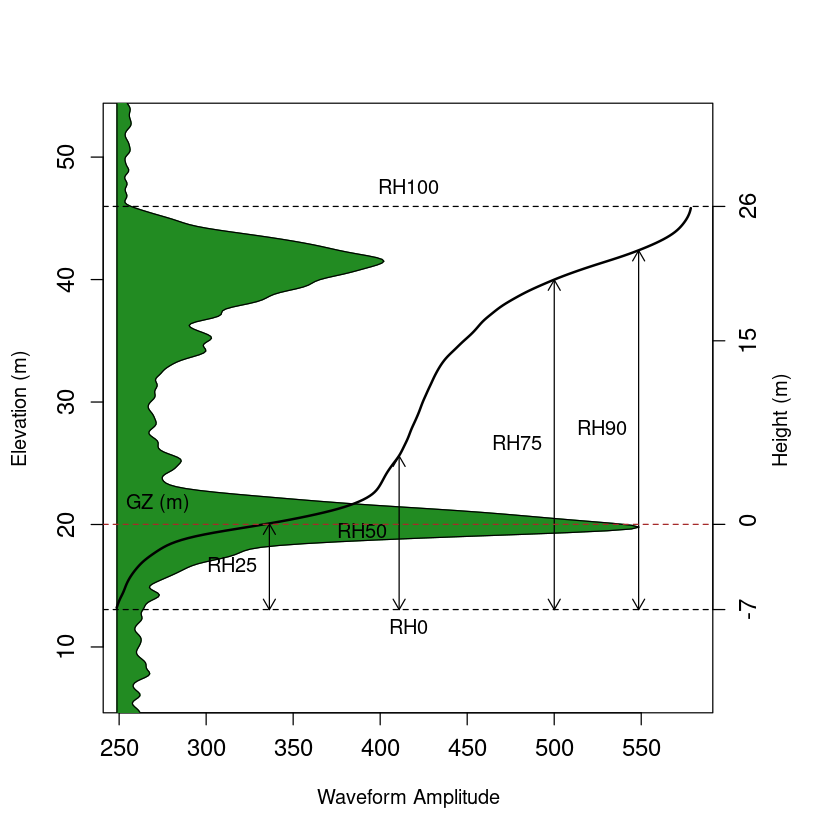

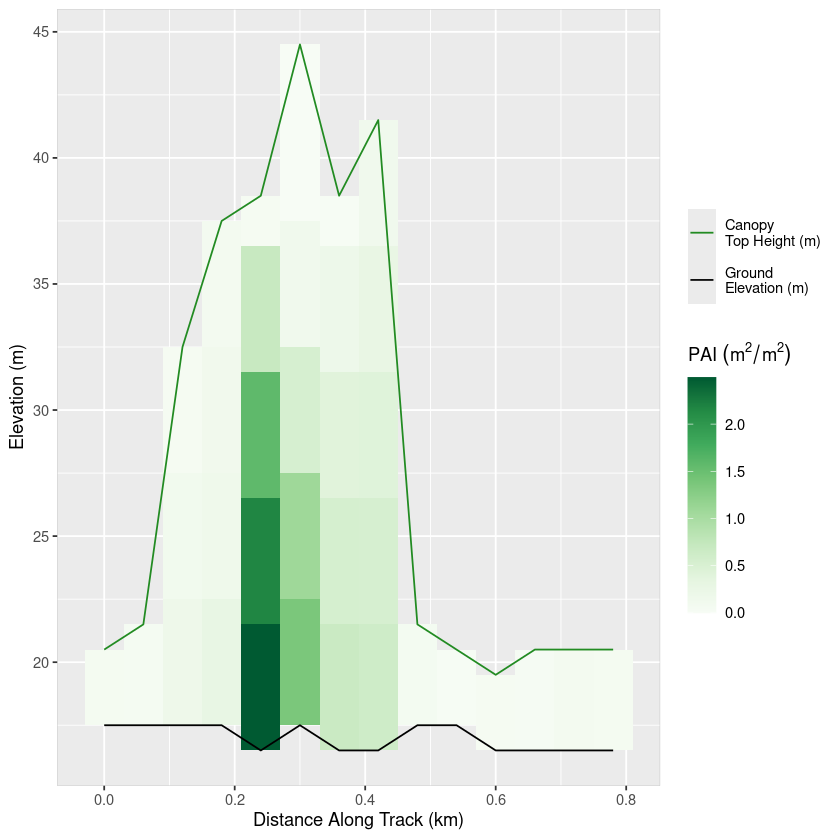

max
<dbl>
33.56


min,max,mean,sd
<dbl>,<dbl>,<dbl>,<dbl>
3.74,33.56,23.3033,7.866386


max
<dbl>
5.154969


poly_id,min,max,mean,sd
<dbl>,<dbl>,<dbl>,<dbl>,<dbl>
NA,-9999,0.9237567,-91.43088,957.7598


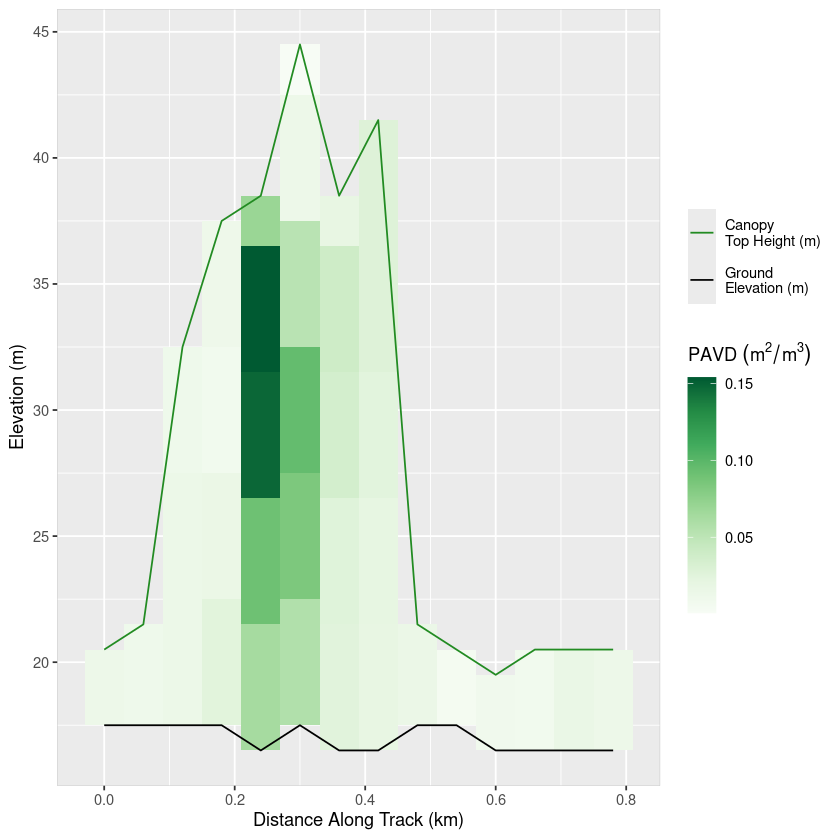

agg_record_41de73978f7c 
                      2

agg_record_41de73978f7c 
                      2

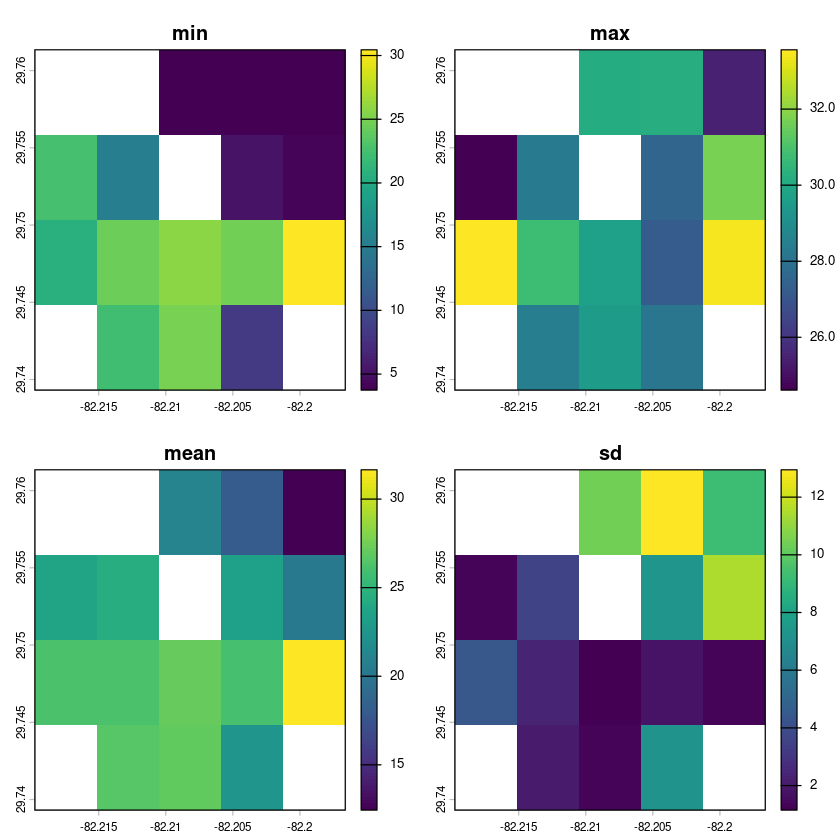

In [14]:
# List all downloaded HDF5 files in the output directory
gedi_files <- list.files(
  path = outdir,
  pattern = "\\.h5$",
  full.names = TRUE
)

cat("Downloaded GEDI files found in the selected directory:\n")
print(basename(gedi_files))

## Separate files by GEDI product


In [ ]:
level1b_files <- gedi_files[grepl("GEDI01_B", basename(gedi_files))]
level2a_files <- gedi_files[grepl("GEDI02_A", basename(gedi_files))]
level2b_files <- gedi_files[grepl("GEDI02_B", basename(gedi_files))]


## Read all GEDI Level 1B files


In [ ]:
gedilevel1b_list <- lapply(level1b_files, readLevel1B)
names(gedilevel1b_list) <- basename(level1b_files)

## Read all GEDI Level 2A files

In [ ]:
gedilevel2a_list <- lapply(level2a_files, readLevel2A)
names(gedilevel2a_list) <- basename(level2a_files)

## Read all GEDI Level 2B files

In [ ]:
gedilevel2b_list <- lapply(level2b_files, readLevel2B)
names(gedilevel2b_list) <- basename(level2b_files)


## Bounding box for clipping

In [ ]:
xmin <- min(ul_lon, lr_lon)
xmax <- max(ul_lon, lr_lon)
ymin <- min(ul_lat, lr_lat)
ymax <- max(ul_lat, lr_lat)

# Read polygon layer for geometry clipping
# Update this file path to your own shapefile if needed
polygon_sf <- read_sf(paste(outdir, polygon_filepath, sep = "/"))

# Check polygon ID field used to create poly_id during geometry clipping
split_by <- "id"

if (!split_by %in% names(polygon_sf)) {
  stop(paste0("The polygon layer does not contain the field '", split_by, "'."))
}

# Reproject polygon layer to geographic coordinates if needed
if (is.na(st_crs(polygon_sf))) {
  stop("The polygon shapefile does not have a defined coordinate reference system.")
}

if (st_crs(polygon_sf)$epsg != 4326) {
  polygon_sf <- st_transform(polygon_sf, 4326)
}

# 4.1 GEDI Level 1B geolocation: raw, bounding box clip, and geometry clip
level1bGeo_raw_list <- lapply(seq_along(gedilevel1b_list), function(i) {
  geo <- getLevel1BGeo(
    level1b = gedilevel1b_list[[i]],
    select = c("elevation_bin0")
  )
  geo$source_file <- names(gedilevel1b_list)[i]
  geo$shot_number <- as.character(geo$shot_number)
  geo
})

level1bGeo_raw <- do.call(rbind, level1bGeo_raw_list)

level1bGeo_bbox_list <- lapply(level1bGeo_raw_list, function(geo) {
  geo_clip <- clipLevel1BGeo(
    level1BGeo = geo,
    xmin = xmin,
    xmax = xmax,
    ymin = ymin,
    ymax = ymax
  )
  if (!is.null(geo_clip) && nrow(geo_clip) > 0) geo_clip else NULL
})

level1bGeo_bbox_list <- Filter(Negate(is.null), level1bGeo_bbox_list)

if (length(level1bGeo_bbox_list) == 0) {
  stop("No GEDI Level 1B shots were found inside the bounding box.")
}

level1bGeo_bbox <- do.call(rbind, level1bGeo_bbox_list)
level1bGeo_bbox$shot_number <- as.character(level1bGeo_bbox$shot_number)

level1bGeo_geom_list <- lapply(level1bGeo_raw_list, function(geo) {
  geo_clip <- clipLevel1BGeoGeometry(
    level1BGeo = geo,
    polygon = polygon_sf,
    split_by = split_by
  )
  if (!is.null(geo_clip) && nrow(geo_clip) > 0) geo_clip else NULL
})

level1bGeo_geom_list <- Filter(Negate(is.null), level1bGeo_geom_list)

if (length(level1bGeo_geom_list) == 0) {
  warning("No GEDI Level 1B shots were found inside the shapefile geometry.")
  level1bGeo_geom <- NULL
} else {
  level1bGeo_geom <- do.call(rbind, level1bGeo_geom_list)
  level1bGeo_geom$shot_number <- as.character(level1bGeo_geom$shot_number)
}

# Use geometry-clipped Level 1B data as the main Level 1B object for later steps
level1bGeo <- level1bGeo_geom


# 4.2 GEDI Level 2A metrics: raw, bounding box clip, and geometry clip
level2AM_raw_list <- lapply(seq_along(gedilevel2a_list), function(i) {
  l2a <- getLevel2AM(gedilevel2a_list[[i]])
  l2a$source_file <- names(gedilevel2a_list)[i]
  l2a$shot_number <- as.character(l2a$shot_number)
  l2a
})

level2AM_raw <- do.call(rbind, level2AM_raw_list)

level2AM_bbox_list <- lapply(level2AM_raw_list, function(l2a) {
  l2a_clip <- clipLevel2AM(
    level2AM = l2a,
    xmin = xmin,
    xmax = xmax,
    ymin = ymin,
    ymax = ymax
  )
  if (!is.null(l2a_clip) && nrow(l2a_clip) > 0) l2a_clip else NULL
})

level2AM_bbox_list <- Filter(Negate(is.null), level2AM_bbox_list)

if (length(level2AM_bbox_list) == 0) {
  warning("No GEDI Level 2A shots were found inside the bounding box.")
  level2AM_bbox <- NULL
} else {
  level2AM_bbox <- do.call(rbind, level2AM_bbox_list)
  level2AM_bbox$shot_number <- as.character(level2AM_bbox$shot_number)
}

level2AM_geom_list <- lapply(level2AM_raw_list, function(l2a) {
  l2a_clip <- clipLevel2AMGeometry(
    level2AM = l2a,
    polygon = polygon_sf,
    split_by = split_by
  )
  if (!is.null(l2a_clip) && nrow(l2a_clip) > 0) l2a_clip else NULL
})

level2AM_geom_list <- Filter(Negate(is.null), level2AM_geom_list)

if (length(level2AM_geom_list) == 0) {
  warning("No GEDI Level 2A shots were found inside the shapefile geometry.")
  level2AM_geom <- NULL
} else {
  level2AM_geom <- do.call(rbind, level2AM_geom_list)
  level2AM_geom$shot_number <- as.character(level2AM_geom$shot_number)
}

# Use geometry-clipped Level 2A data as the main Level 2A object for later steps
level2AM <- level2AM_geom


# 4.3 GEDI Level 2B metrics: raw, bounding box clip, and geometry clip
level2BVPM_raw_list <- lapply(seq_along(gedilevel2b_list), function(i) {
  l2b <- getLevel2BVPM(gedilevel2b_list[[i]])
  l2b$source_file <- names(gedilevel2b_list)[i]
  l2b$shot_number <- as.character(l2b$shot_number)
  l2b
})

level2BVPM_raw <- do.call(rbind, level2BVPM_raw_list)

level2BVPM_bbox_list <- lapply(level2BVPM_raw_list, function(l2b) {
  l2b_clip <- clipLevel2BVPM(
    level2BVPM = l2b,
    xmin = xmin,
    xmax = xmax,
    ymin = ymin,
    ymax = ymax
  )
  if (!is.null(l2b_clip) && nrow(l2b_clip) > 0) l2b_clip else NULL
})

level2BVPM_bbox_list <- Filter(Negate(is.null), level2BVPM_bbox_list)

if (length(level2BVPM_bbox_list) == 0) {
  warning("No GEDI Level 2B shots were found inside the bounding box.")
  level2BVPM_bbox <- NULL
} else {
  level2BVPM_bbox <- do.call(rbind, level2BVPM_bbox_list)
  level2BVPM_bbox$shot_number <- as.character(level2BVPM_bbox$shot_number)
}

level2BVPM_geom_list <- lapply(level2BVPM_raw_list, function(l2b) {
  l2b_clip <- clipLevel2BVPMGeometry(
    level2BVPM = l2b,
    polygon = polygon_sf,
    split_by = split_by
  )
  if (!is.null(l2b_clip) && nrow(l2b_clip) > 0) l2b_clip else NULL
})

level2BVPM_geom_list <- Filter(Negate(is.null), level2BVPM_geom_list)

if (length(level2BVPM_geom_list) == 0) {
  warning("No GEDI Level 2B shots were found inside the shapefile geometry.")
  level2BVPM_geom <- NULL
} else {
  level2BVPM_geom <- do.call(rbind, level2BVPM_geom_list)
  level2BVPM_geom$shot_number <- as.character(level2BVPM_geom$shot_number)
}

# Use geometry-clipped Level 2B data as the main Level 2B object for later steps
level2BVPM <- level2BVPM_geom

# Quick checks
cat("\nGEDI Level 1B tile coordinate range:\n")
cat("Longitude:", range(level1bGeo_raw$longitude_bin0, na.rm = TRUE), "\n")
cat("Latitude: ", range(level1bGeo_raw$latitude_bin0, na.rm = TRUE), "\n")

cat("\nGEDI Level 1B bounding box coordinate range:\n")
cat("Longitude:", range(level1bGeo_bbox$longitude_bin0, na.rm = TRUE), "\n")
cat("Latitude: ", range(level1bGeo_bbox$latitude_bin0, na.rm = TRUE), "\n")

cat("\nGEDI Level 1B shapefile coordinate range:\n")
cat("Longitude:", range(level1bGeo_geom$longitude_bin0, na.rm = TRUE), "\n")
cat("Latitude: ", range(level1bGeo_geom$latitude_bin0, na.rm = TRUE), "\n")


# 4.4 Plot tile, bounding box, and aoi-clipped footprints
# Build bounding box polygon
bbox_sf <- st_as_sfc(
  st_bbox(c(xmin = xmin, xmax = xmax, ymin = ymin, ymax = ymax), crs = st_crs(4326))
)

# Create a 10 km buffer around the bounding box for visualization only
bbox_buffer_10km <- bbox_sf %>%
  st_buffer(10000)

# Convert raw Level 1B geolocation to sf for spatial filtering
level1bGeo_raw_sf <- st_as_sf(
  level1bGeo_raw,
  coords = c("longitude_bin0", "latitude_bin0"),
  crs = 4326,
  remove = FALSE
)

# Keep only raw GEDI shots within 10 km of the bounding box for plotting
level1bGeo_raw_plot <- st_intersection(level1bGeo_raw_sf, bbox_buffer_10km)

# Build leaflet map
leaflet() %>%
  addProviderTiles(providers$Esri.WorldImagery) %>%
  addPolygons(
    data = bbox_sf,
    color = "cyan",
    weight = 2,
    fill = FALSE,
    group = "Bounding box"
  ) %>%
  addPolygons(
    data = polygon_sf,
    color = "yellow",
    weight = 2,
    fill = FALSE,
    group = "Shapefile"
  ) %>%
  addCircleMarkers(
    data = level1bGeo_raw_plot,
    lng = ~longitude_bin0,
    lat = ~latitude_bin0,
    radius = 2,
    stroke = FALSE,
    fillOpacity = 0.9,

    color = "red",
    group = "Tile footprints"
  ) %>%
  addCircleMarkers(
    data = level1bGeo_bbox,
    lng = ~longitude_bin0,
    lat = ~latitude_bin0,
    radius = 2,
    stroke = FALSE,
    fillOpacity = 0.9,

    color = "cyan",
    group = "BBox footprints"
  ) %>%
  addCircleMarkers(
    data = level1bGeo_geom,
    lng = ~longitude_bin0,
    lat = ~latitude_bin0,
    radius = 2,
    stroke = FALSE,
    fillOpacity = 0.9,

    color = "yellow",
    group = "AOI footprints"
  ) %>%
  addLayersControl(
    overlayGroups = c(
      "BBox",
      "AOI",
      "Tile footprints",
      "BBox footprints",
      "AOI footprints"
    ),
    options = layersControlOptions(collapsed = FALSE)
  ) %>%
  addLegend(
    position = "bottomright",
    colors = c("red", "cyan", "yellow"),
    labels = c("Tile footprints", "BBox footprints", "AOI footprints"),
    title = "GEDI footprints"
  ) %>%
  fitBounds(
    lng1 = xmin,
    lat1 = ymin,
    lng2 = xmax,
    lat2 = ymax
  )


# #########################################################################
# 5. GEDI L1B Geolocated Waveform Data ------------------------------------
# 5.1. Get GEDI pulse geolocation (GEDI Level 1B
# In this section, the script converts the clipped GEDI Level 1B pulse
# geolocation data to an sf object and exports it as a shapefile.

# Preview the clipped Level 1B table
head(level1bGeo)

# Convert the clipped table to an sf object
level1bGeo_sf <- st_as_sf(
  level1bGeo,
  coords = c("longitude_bin0", "latitude_bin0"),
  crs = 4326,
  remove = FALSE
)

# Remove any previous shapefile with the same name
shp_out <- file.path(outdir, "GEDI_Level1B_Geolocation.shp")
if (file.exists(shp_out)) file.remove(list.files(outdir,
                                                 pattern = "^GEDI_Level1B_Geolocation\\.(shp|shx|dbf|prj|cpg)$",
                                                 full.names = TRUE
))

# Export clipped geolocation
write_sf(level1bGeo_sf, shp_out, delete_layer = TRUE)
cat("Clipped GEDI Level 1B geolocation shapefile saved to:\n", shp_out, "\n")


# 5.2. Plot GEDI pulse geolocation (GEDI Level 1B)
# In this section, the script visualizes the merged GEDI Level 1B pulse
# geolocation using a leaflet interactive map.
level1b_map <- leaflet() %>%
  addProviderTiles(providers$Esri.WorldImagery) %>%
  addCircleMarkers(
    lng = level1bGeo$longitude_bin0,
    lat = level1bGeo$latitude_bin0,
    radius = 1,
    opacity = 1,
    color = "red"
  ) %>%
  addScaleBar(options = list(imperial = FALSE)) %>%
  addLegend(
    colors = "red",
    labels = "Footprints",
    title = "GEDI Level 1B"
  ) %>%
  setView(
    lng = mean(level1bGeo$longitude_bin0, na.rm = TRUE),
    lat = mean(level1bGeo$latitude_bin0, na.rm = TRUE),
    zoom = 15
  )

print(level1b_map)


# 5.3. Extract and plot a GEDI full waveform (GEDI Level 1B)
# In this section, the script extracts the full waveform for a selected
# GEDI shot and plots it in two ways:
# - Absolute waveform amplitude
# - Relative waveform amplitude
#
# The shot number must exist in the clipped Level 1B geolocation table.

# Define the shot number to be plotted
head(level1bGeo)
shot_number <- "72530800300429393"

# Check whether the selected shot exists in the clipped Level 1B data
if (!shot_number %in% level1bGeo$shot_number) {
  stop("The selected shot_number was not found in the clipped GEDI Level 1B data.")
}

# Find which Level 1B file contains the selected shot
source_file_wf <- unique(level1bGeo$source_file[level1bGeo$shot_number == shot_number])[1]

if (is.na(source_file_wf) || length(source_file_wf) == 0) {
  stop("Could not identify the source Level 1B file for the selected shot_number.")
}

# Match the source file to the corresponding Level 1B object in memory
wf_index <- match(source_file_wf, names(gedilevel1b_list))

if (is.na(wf_index)) {
  stop("The source Level 1B file for the selected shot_number was not found in the Level 1B file list.")
}

# Extract the waveform for the selected shot
wf <- getLevel1BWF(
  level1b = gedilevel1b_list[[wf_index]],
  shot_number = shot_number
)

# Plot the waveform in absolute and relative form
par(mfrow = c(1, 2), mar = c(4, 4, 1, 1), cex.axis = 1.2)

plot(
  wf,
  relative = FALSE,
  polygon = TRUE,
  type = "l",
  lwd = 2,
  col = "forestgreen",
  xlab = "Waveform amplitude",
  ylab = "Elevation (m)"
)
grid()

plot(
  wf,
  relative = TRUE,
  polygon = FALSE,
  type = "l",
  lwd = 2,
  col = "forestgreen",
  xlab = "Waveform amplitude (%)",
  ylab = "Elevation (m)"
)
grid()


# #########################################################################
# 6. GEDI L2A Elevation and Height Metrics Data ---------------------------
# 6.1. Get GEDI elevation and height metrics (GEDI Level 2A)
# In this section, the script uses the clipped GEDI Level 2A data created in
# the previous steps, previews selected elevation and canopy height metrics,
# converts the table to an sf object, and exports it as a shapefile.

# Preview selected GEDI Level 2A variables
head(level2AM[, c("beam", "shot_number", "elev_highestreturn", "elev_lowestmode", "rh100")])

# Convert the clipped Level 2A table to an sf object using longitude and latitude
level2AM_sf <- st_as_sf(
  level2AM,
  coords = c("lon_lowestmode", "lat_lowestmode"),
  crs = 4326,
  remove = FALSE
)

# Remove any previous shapefile with the same name
l2a_out <- file.path(outdir, "GEDI_Level2A_Metrics.shp")
old_l2a <- list.files(
  outdir,
  pattern = "^GEDI_Level2A_Metrics\\.(shp|shx|dbf|prj|cpg)$",
  full.names = TRUE
)
if (length(old_l2a) > 0) file.remove(old_l2a)

# Export the clipped Level 2A metrics as a shapefile
write_sf(level2AM_sf, l2a_out, delete_layer = TRUE)
cat("Clipped GEDI Level 2A metrics shapefile saved to:\n", l2a_out, "\n")


# 6.2. Plot waveform metrics for a selected GEDI shot
# In this section, the script plots the full waveform together with selected
# relative height (RH) metrics for a chosen GEDI shot number.
#
# Because multiple GEDI files were read and stored in lists, the script first
# identifies the Level 1B and Level 2A source files associated with the
# selected shot and then uses the corresponding objects for plotting.

# Identify the source Level 1B file for the selected shot
source_file_l1b <- unique(
  level1bGeo$source_file[level1bGeo$shot_number == shot_number]
)[1]

# Identify the source Level 2A file for the selected shot
source_file_l2a <- unique(
  level2AM$source_file[level2AM$shot_number == shot_number]
)[1]

# Match source filenames to the corresponding objects in memory
l1b_index <- match(source_file_l1b, names(gedilevel1b_list))
l2a_index <- match(source_file_l2a, names(gedilevel2a_list))

par(mfrow = c(1, 1), mar = c(4, 4, 1, 1), cex.axis = 1.2)
plotWFMetrics(
  level1b = gedilevel1b_list[[l1b_index]],
  level2a = gedilevel2a_list[[l2a_index]],
  shot_number = shot_number,
  rh = c(25, 50, 75, 90)
)


# #########################################################################
# 7. GEDI L2B Canopy Cover and Vertical Profile Metrics Data --------------
# 7.1. Get GEDI vegetation biophysical variables (GEDI Level 2B)
# In this section, the script uses the clipped GEDI Level 2B vegetation bio-
# physical variables created in the previous steps, previews selected variables,
# converts the table to an sf object, and exports it as a shapefile.

# Preview selected GEDI Level 2B variables
head(level2BVPM[, c("beam", "shot_number", "pai", "fhd_normal", "omega", "pgap_theta", "cover")])

# Preview the full table structure
head(level2BVPM)

# Convert the clipped Level 2B table to an sf object using longitude and latitude
level2BVPM_sf <- st_as_sf(
  level2BVPM,
  coords = c("longitude_lastbin", "latitude_lastbin"),
  crs = 4326,
  remove = FALSE
)

# Remove any previous shapefile with the same name
l2b_out <- file.path(outdir, "GEDI_Level2B_BiophysicalVariables.shp")
old_l2b <- list.files(
  outdir,
  pattern = "^GEDI_Level2B_BiophysicalVariables\\.(shp|shx|dbf|prj|cpg)$",
  full.names = TRUE
)
if (length(old_l2b) > 0) file.remove(old_l2b)

# Export the clipped Level 2B biophysical variables as a shapefile
write_sf(level2BVPM_sf, l2b_out, delete_layer = TRUE)
cat("Clipped GEDI Level 2B biophysical variables shapefile saved to:\n", l2b_out, "\n")


# 7.2. Get and plot PAI and PAVD profiles (GEDI Level 2B) ------------------
# In this section, the script extracts Plant Area Index (PAI) and Plant Area
# Volume Density (PAVD) profiles from the GEDI Level 2B files already loaded
# in memory. Because the workflow already applies spatial clipping in the
# previous steps, no additional clipping is performed here.
#
# The outputs are merged into single tables and then plotted for a selected
# GEDI beam.

# Extract GEDI Level 2B PAI profiles from all files
level2BPAIProfile_list <- lapply(seq_along(gedilevel2b_list), function(i) {
  pai <- getLevel2BPAIProfile(gedilevel2b_list[[i]])
  pai$source_file <- names(gedilevel2b_list)[i]
  pai
})

# Merge all PAI profile tables into a single object
level2BPAIProfile <- do.call(rbind, level2BPAIProfile_list)
level2BPAIProfile$shot_number <- as.character(level2BPAIProfile$shot_number)

# Extract GEDI Level 2B PAVD profiles from all files
level2BPAVDProfile_list <- lapply(seq_along(gedilevel2b_list), function(i) {
  pavd <- getLevel2BPAVDProfile(gedilevel2b_list[[i]])
  pavd$source_file <- names(gedilevel2b_list)[i]
  pavd
})

# Merge all PAVD profile tables into a single object
level2BPAVDProfile <- do.call(rbind, level2BPAVDProfile_list)
level2BPAVDProfile$shot_number <- as.character(level2BPAVDProfile$shot_number)

# Keep only shots already present in the clipped Level 2B metric table
if (!is.null(level2BVPM)) {
  valid_shots <- unique(level2BVPM$shot_number)

  level2BPAIProfile <- level2BPAIProfile[
    level2BPAIProfile$shot_number %in% valid_shots,
  ]

  level2BPAVDProfile <- level2BPAVDProfile[
    level2BPAVDProfile$shot_number %in% valid_shots,
  ]
}

# Preview selected variables
if (nrow(level2BPAIProfile) > 0) {
  head(level2BPAIProfile[, c("beam", "shot_number", "pai_z0_5m", "pai_z5_10m")])
} else {
  warning("No GEDI Level 2B PAI profiles matched the clipped Level 2B shots.")
}

if (nrow(level2BPAVDProfile) > 0) {
  head(level2BPAVDProfile[, c("beam", "shot_number", "pavd_z0_5m", "pavd_z5_10m")])
} else {
  warning("No GEDI Level 2B PAVD profiles matched the clipped Level 2B shots.")
}

# Specify the GEDI beam to be plotted
head(level2BPAVDProfile$beam)
beam <- "BEAM0101"

# Plot Level 2B PAI profile for the selected beam
if (nrow(level2BPAIProfile) > 0 && beam %in% level2BPAIProfile$beam) {
  gPAIprofile <- plotPAIProfile(level2BPAIProfile, beam = beam, elev = TRUE)
} else {
  warning("The selected beam was not found in the available Level 2B PAI profile data.")
}

# Plot Level 2B PAVD profile for the selected beam
if (nrow(level2BPAVDProfile) > 0 && beam %in% level2BPAVDProfile$beam) {
  gPAVDprofile <- plotPAVDProfile(level2BPAVDProfile, beam = beam, elev = TRUE)
} else {
  warning("The selected beam was not found in the available Level 2B PAVD profile data.")
}


# #########################################################################
# 8. Compute polygon-based statistics for GEDI metrics --------------------
# In this section, the script computes summary statistics for the clipped
# GEDI Level 2A and Level 2B data.

# Define your own function to compute multiple summary statistics
mySetOfMetrics <- function(x) {
  metrics <- list(
    min  = min(x, na.rm = TRUE),
    max  = max(x, na.rm = TRUE),
    mean = mean(x, na.rm = TRUE),
    sd   = sd(x, na.rm = TRUE)
  )
  return(metrics)
}

# 8.1 Compute polygon-based statistics for GEDI Level 2A
# Compute the maximum RH100 by polygon
rh100max_st <- polyStatsLevel2AM(
  level2AM,
  func = max(rh100, na.rm = TRUE),
  id = NULL
); rh100max_st

# Compute multiple RH100 statistics by polygon
rh100metrics_st <- polyStatsLevel2AM(
  level2AM,
  func = mySetOfMetrics(rh100),
  id = NULL
)

head(rh100metrics_st)


# 8.2. Compute polygon-based statistics for GEDI Level 2B
# Compute the maximum Plant Area Index (PAI) for all clipped data
pai_max <- polyStatsLevel2BVPM(
  level2BVPM,
  func = max(pai, na.rm = TRUE),
  id = NULL
); pai_max

# Compute multiple canopy cover statistics by polygon
cover_metrics_st <- polyStatsLevel2BVPM(
  level2BVPM,
  func = mySetOfMetrics(cover),
  id = "poly_id"
)

head(cover_metrics_st)


# ##########################################################################
# 9. Compute gridded descriptive statistics --------------------------------
# 9.1. Gridded statistics of GEDI Level 2A metrics
# In this section, the script computes gridded summary statistics for the
# RH100 metric from the clipped GEDI Level 2A data. The output is a multi-layer
# raster with four statistics for each grid cell: min, max, mean, and std.
#
# Note:
# - The function mySetOfMetrics() must already be defined earlier in the script.
# - The grid resolution is defined in geographic degrees.
# - A resolution of 0.005 degrees is approximately 500 m at the equator.

# Compute gridded statistics for RH100
rh100metrics <- gridStatsLevel2AM(
  level2AM = level2AM,
  func = mySetOfMetrics(rh100),
  res = 0.005
)

plot(rh100metrics)

# Convert SpatRaster to RasterBrick
rh100metrics_raster <- raster::brick(rh100metrics)

rh100maps <- rasterVis::levelplot(
  rh100metrics_raster,
  layout = c(1, 4),
  margin = FALSE,
  xlab = "Longitude (degree)",
  ylab = "Latitude (degree)",
  colorkey = list(
    space = "right",
    labels = list(at = seq(0, 35, 5), font = 4),
    axis.line = list(col = "black"),
    width = 1
  ),
  par.settings = list(
    strip.border = list(col = "gray"),
    strip.background = list(col = "gray"),
    axis.line = list(col = "gray")
  ),
  scales = list(draw = TRUE),
  col.regions = viridis,
  at = seq(0, 35, len = 101),
  names.attr = c("rh100 min", "rh100 max", "rh100 mean", "rh100 sd")
)

# Export maps as a PNG image
png(
  filename = file.path(outdir, "GEDI_Level2A_RH100_GridStats.png"),
  width = 6,
  height = 8,
  units = "in",
  res = 300
)
print(rh100maps)
dev.off()


# 9.2. Gridded statistics of GEDI Level 2B metrics
# In this section, the script computes gridded summary statistics for the
# Plant Area Index (PAI) from the clipped GEDI Level 2B data. The output is
# a multi-layer raster with four statistics for each grid cell: min, max,
# mean, and std.
#
# Note:
# - The function mySetOfMetrics() must already be defined earlier in the script.
# - The grid resolution is defined in geographic degrees.
# - A resolution of 0.005 degrees is approximately 500 m at the equator.

# Replace invalid PAI values with NA
level2BVPM$pai[level2BVPM$pai == -9999] <- NA

# Compute gridded statistics for PAI
pai_metrics <- gridStatsLevel2BVPM(
  level2BVPM = level2BVPM,
  func = mySetOfMetrics(pai),
  res = 0.005
)

plot(rh100metrics)

# If needed, convert to Raster* so rasterVis::levelplot() works
pai_metrics_raster <- raster::brick(pai_metrics)

# View maps
pai_maps <- rasterVis::levelplot(
  pai_metrics_raster,
  layout = c(1, 4),
  margin = FALSE,
  xlab = "Longitude (degree)",
  ylab = "Latitude (degree)",
  colorkey = list(
    space = "right",
    labels = list(at = seq(0, 6, 1), font = 4),
    axis.line = list(col = "black"),
    width = 1
  ),
  par.settings = list(
    strip.border = list(col = "gray"),
    strip.background = list(col = "gray"),
    axis.line = list(col = "gray")
  ),
  scales = list(draw = TRUE),
  col.regions = viridis,
  at = seq(0, 6, len = 101),
  names.attr = c("PAI min", "PAI max", "PAI mean", "PAI sd")
)

# Export maps
png(
  filename = file.path(outdir, "GEDI_Level2B_PAI_GridStats.png"),
  width = 6,
  height = 8,
  units = "in",
  res = 300
)
print(pai_maps)
dev.off()